## Importing Libraries

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
# Text Processing
import re
import nltk
import emoji
from nltk.stem import WordNetLemmatizer

In [3]:
# Download required NLTK resources
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences
from sklearn.utils.class_weight import compute_class_weight

In [6]:
# Machine Learning Models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [7]:
# Deep Learning Models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, Bidirectional, GlobalAveragePooling1D, Dropout, LSTM

In [8]:
# Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [9]:
# Model Deployment
import gradio as gr
from tensorflow.keras.models import load_model
import pickle

d:\Sentiment_Analysis\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
df = pd.read_csv('sentiment_data.csv', index_col=0)
# index_col=0 --> To avoid seeing the index column twice
df

,Comment,Sentiment
0,lets forget apple pay required brand new iphon...,1
1,nz retailers don’t even contactless credit car...,0
2,forever acknowledge channel help lessons ideas...,2
3,whenever go place doesn’t take apple pay doesn...,0
4,apple pay convenient secure easy use used kore...,2
...,...,...
241921,crores paid neerav modi recovered congress lea...,0
241922,dear rss terrorist payal gawar modi killing pl...,0
241923,cover interaction forum left,1
241924,big project came india modi dream project happ...,1


## Exploratory Data Analysis

##### Chek null values.
##### Check the class distribution (Negative, Neutral, Positive).
##### Look at review lengths.
##### Visualize the most common words using WordClouds.
##### Check comments containing emojis.
##### Check special characters.

In [11]:
# Check Null Values
df.isna().sum()

Comment      217
Sentiment      0
dtype: int64

In [12]:
# Let's drop them
df.dropna(inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_17156\4173382935.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='Blues')


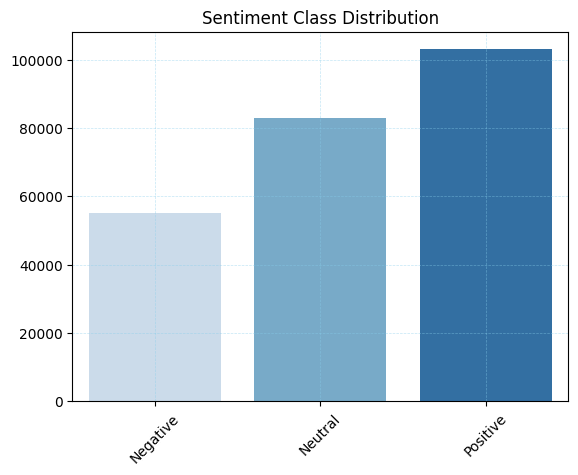

In [13]:
# Class Distribution
sns.countplot(x='Sentiment', data=df, palette='Blues')
plt.grid(linestyle='--', alpha=0.5, linewidth=0.5, color='skyblue')
plt.xticks([0,1,2], ['Negative', 'Neutral', 'Positive'], rotation=45)
plt.title('Sentiment Class Distribution')
plt.xlabel('')
plt.ylabel('')
plt.show()

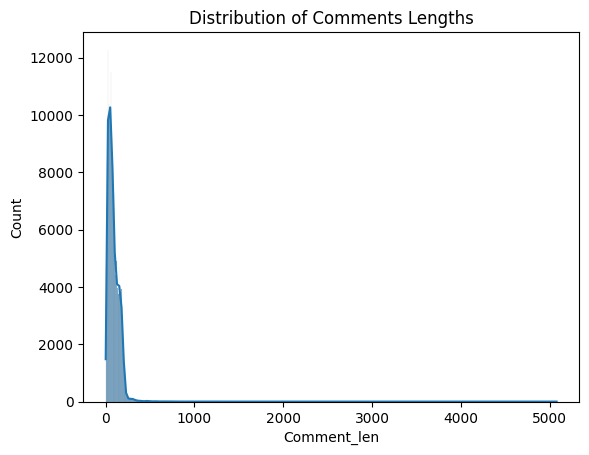

In [14]:
# Review the lengths of the comments
df['Comment_len'] = df['Comment'].apply(len)
sns.histplot(x='Comment_len', data=df, kde=True)
plt.title('Distribution of Comments Lengths')
plt.show()

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Sentiment,240928.0,1.198985,0.785386,0.0,1.0,1.0,2.0,2.0
Comment_len,240928.0,87.661272,71.974148,1.0,41.0,72.0,124.0,5080.0


In [16]:
# Let's see how many comments that have length greater than or equal 1000
len(df[df['Comment_len'] >= 1000])

100

In [17]:
# Checking it's sentiment
df[df['Comment_len'] >= 1000]['Sentiment'].value_counts()

Sentiment
1    52
2    32
0    16
Name: count, dtype: int64

In [18]:
# WordCloud
positive_comments = " ".join(df[df["Sentiment"]==2]["Comment"])
negative_comments = " ".join(df[df["Sentiment"]==0]["Comment"])

wordcloud_pos = WordCloud(width=800, height=400, background_color="white").generate(positive_comments)
wordcloud_neg = WordCloud(width=800, height=400, background_color="black").generate(negative_comments)

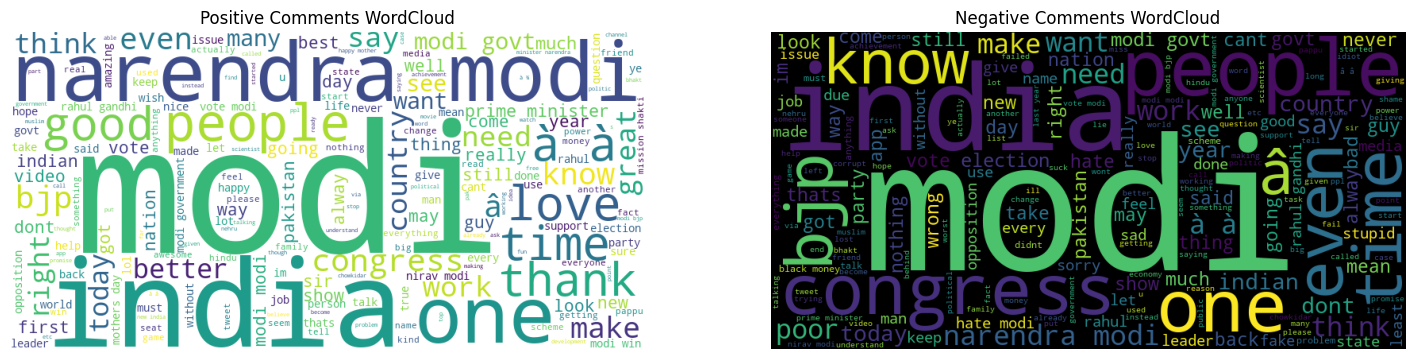

In [19]:
plt.figure(figsize=(18,9))
plt.subplot(1,2,1)
plt.imshow(wordcloud_pos)
plt.title("Positive Comments WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wordcloud_neg)
plt.title("Negative Comments WordCloud")
plt.axis("off")
plt.show()


In [20]:
# Check the emojis
emoji_pattern = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons [😀 → 🙏]
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs [🌀 → 🗿]
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols [🚀 → 🚿]
                           u"\U0001F1E0-\U0001F1FF"  # flags [🇦 → 🇿]
                           u"\U00002700-\U000027BF"  # Dingbats [✀ → ➿]
                           u"\U000024C2-\U0001F251"  # Enclosed characters [Ⓜ → 🉑]
                           "]+", flags=re.UNICODE)
# Find comments containing emojis and store them
df['emojis'] = df['Comment'].apply(lambda x: ''.join(emoji_pattern.findall(str(x))))

# Number of comments that have at least one emoji
num_comments_with_emojis = df['emojis'].apply(lambda x: len(x) > 0).sum()

print("\nNumber of comments with emojis:", num_comments_with_emojis)

# See some examples
print("\nSample emojis found:")
df[df['emojis'] != ''][['Comment', 'emojis']].sample(30)


Number of comments with emojis: 456

Sample emojis found:


,Comment,emojis
8876,𝗧𝗿𝗲𝗻𝗱𝗶𝗻𝗴 𝗮𝗱𝘂𝗹𝘁 𝗽𝗼𝗿𝗻 𝘃𝗶𝗱𝗲𝗼𝘀 𝗼𝗻𝗹𝘆 alles sehr sch...,𝗧𝗿𝗲𝗻𝗱𝗶𝗻𝗴𝗮𝗱𝘂𝗹𝘁𝗽𝗼𝗿𝗻𝘃𝗶𝗱𝗲𝗼𝘀𝗼𝗻𝗹𝘆
9710,那个鳄鱼头我都可以轻松剥掉他们居然不行装的一定是装的后面脑袋都没有了,那个鳄鱼头我都可以轻松剥掉他们居然不行装的一定是装的后面脑袋都没有了
62028,great app love gardening app also explained di...,👏
57543,really like app though ive used week suggestio...,😊
64469,looked good doesnt work scheduled simple tasks...,😳
56208,app crash often happensand cant even open app ...,😑
51026,fun way get habits makes want things real life...,😅
59683,uninstall app wants sell every small feature ✔...,✔
17515,► next days get art pro plus program totally f...,►►►►
48267,app kept organization relatively simple past s...,☆


## Data Preprocessing

##### Remove non-English words → keep only English letters and emojis.
##### Lemmatization → reduce words to their base form (e.g., running → run).
##### Convert emojis to words → map 🙂 → "smile", 🙁 → "sad", etc.
##### Tokenization → convert words into integer indices.
##### Padding → make all sequences the same length.
##### Train-test split → separate data for training and validation.
##### Feature Engineering → TF-IDF (for ML baselines) or Word2Vec/Embeddings (for DL models).

In [21]:
# Remove non-English words and keep the emojis

def remove_non_english(text):
    pattern = re.compile(
        r"[^A-Za-z\u2600-\u26FF\u2700-\u27BF\U0001F300-\U0001F5FF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF\U0001F700-\U0001F77F\U0001F900-\U0001F9FF ]+",
        flags=re.UNICODE
    )
    return pattern.sub("", text)

df["Cleaned_Comment"] = df["Comment"].apply(remove_non_english)

In [22]:
for _, row in df[df['emojis'] != ''].sample(10).iterrows():
    print('Before:', str(row['Comment']))
    print()
    print('After:', str(row['Cleaned_Comment']))
    print('-'*40)

Before: really loved app everything wanted feel like still room improvement app personal opinion though better could add screen heat map heat map would colored days user least one task another one could letting user add notes subtasks also 🙏

After: really loved app everything wanted feel like still room improvement app personal opinion though better could add screen heat map heat map would colored days user least one task another one could letting user add notes subtasks also 🙏
----------------------------------------
Before: seriously womans imagination never runs dry rps especially hair series really shown us inquisitive ingenious female asmr really feel like originality gives pleasure also inspires many people put thinking caps along seems enjoying making types videos personally makes enjoy even honestly cant wait see unique n amazing posts much love well female hope youre well stay safe keep spectacular work v ☆ im earlyyyy btw

After: seriously womans imagination never runs dry r

In [23]:
df = df[df['Cleaned_Comment'] != '']
df.head()

,Comment,Sentiment,Comment_len,emojis,Cleaned_Comment
0,lets forget apple pay required brand new iphon...,1,231,,lets forget apple pay required brand new iphon...
1,nz retailers don’t even contactless credit car...,0,113,,nz retailers dont even contactless credit card...
2,forever acknowledge channel help lessons ideas...,2,114,,forever acknowledge channel help lessons ideas...
3,whenever go place doesn’t take apple pay doesn...,0,328,,whenever go place doesnt take apple pay doesnt...
4,apple pay convenient secure easy use used kore...,2,93,,apple pay convenient secure easy use used kore...


In [24]:
# Lemmatization
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

df["Cleaned_Lemma_Comment"] = df["Cleaned_Comment"].apply(lemmatize_text)


In [25]:
for _, row in df.sample(10).iterrows():
    print('Before Lemmatization:', str(row['Cleaned_Comment']))
    print()
    print('After Lemmatization:', str(row['Cleaned_Lemma_Comment']))
    print('-'*40)

Before Lemmatization: declared would implemented rashly like

After Lemmatization: declared would implemented rashly like
----------------------------------------
Before Lemmatization: bjp must stop seeking merit based support must issue based like islamic support pseudosecular parties progress development issue hindus

After Lemmatization: bjp must stop seeking merit based support must issue based like islamic support pseudosecular party progress development issue hindu
----------------------------------------
Before Lemmatization: election commission joke

After Lemmatization: election commission joke
----------------------------------------
Before Lemmatization: crlane ive seen pictures dx havent seen person love kindle im everyday

After Lemmatization: crlane ive seen picture dx havent seen person love kindle im everyday
----------------------------------------
Before Lemmatization: excellent point

After Lemmatization: excellent point
----------------------------------------
Befor

In [27]:
def clean_text(text):
    text = str(text)

    # Step 1: demojize first
    text = emoji.demojize(text)

    # Step 2: replace ":emoji_name:" with "space + emoji_name + space"
    text = re.sub(r':([a-zA-Z0-9_]+):', r' \1 ', text)

    # Step 3: remove non-ASCII chars (foreign text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)

    # Step 4: remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [28]:
df['Cleaned_Comment'] = df['Cleaned_Lemma_Comment'].apply(clean_text)

In [29]:
for _, row in df[df['emojis'] != ''].sample(10).iterrows():
    print('Before:', str(row['Cleaned_Lemma_Comment']))
    print()
    print('After:', str(row['Cleaned_Comment']))
    print('-'*40)

Before: great app kink need ironing ill update theyre done love app use daily intended 😊

After: great app kink need ironing ill update theyre done love app use daily intended smiling_face_with_smiling_eyes
----------------------------------------
Before: app good cant access habit need premium access 🙅🤷

After: app good cant access habit need premium access person_gesturing_NO person_shrugging
----------------------------------------
Before: whole world comfort food u uk

After: whole world comfort food u uk
----------------------------------------
Before: hermosa eleccin los mortales abian apreciado tan hermosa mujer elecciones culturales hopi sweeter sun hotter joonie cooler yoongy butter son unos de los mejores conciertos maas se la la elecciones cinematogrficas artsticas son brillantes referencias culturales europeas realmente interesantes ojal la cultura europea se representara m menudo tan bellamente puedo dejar de decir oh esto e hermoso lo largo del video luz en serio el que s

In [31]:
df.tail()

,Comment,Sentiment,Comment_len,emojis,Cleaned_Comment,Cleaned_Lemma_Comment
241921,crores paid neerav modi recovered congress lea...,0,79,,crore paid neerav modi recovered congress lead...,crore paid neerav modi recovered congress lead...
241922,dear rss terrorist payal gawar modi killing pl...,0,223,,dear rss terrorist payal gawar modi killing pl...,dear rss terrorist payal gawar modi killing pl...
241923,cover interaction forum left,1,28,,cover interaction forum left,cover interaction forum left
241924,big project came india modi dream project happ...,1,58,,big project came india modi dream project happ...,big project came india modi dream project happ...
241925,ever listen like gurukul discipline maintained...,2,158,,ever listen like gurukul discipline maintained...,ever listen like gurukul discipline maintained...


In [32]:
X = df['Cleaned_Comment']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

## Models Training

### Machine Learning Models
#### Logistic Regression
 A linear model that works well for text classification with TF-IDF features.
#### Random Forest
 An ensemble method that builds multiple decision trees and averages their predictions.

### Logistic Regression

In [35]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=5000, C=10, penalty='l2', solver='saga', class_weight="balanced")
log_reg.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_tfidf)

d:\Sentiment_Analysis\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [37]:
# Evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.74      0.72     11021
           1       0.75      0.81      0.78     16550
           2       0.86      0.78      0.82     20609

    accuracy                           0.78     48180
   macro avg       0.77      0.78      0.77     48180
weighted avg       0.79      0.78      0.78     48180



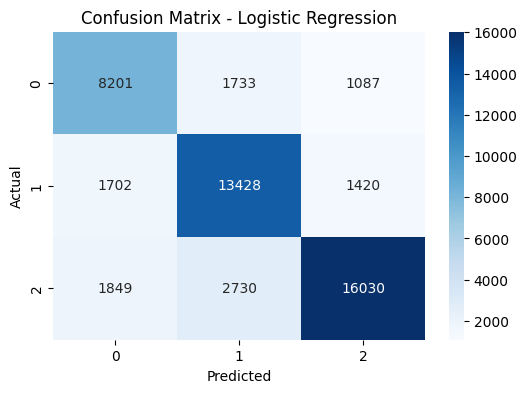

In [38]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## RandomForest

In [39]:
# model fitting
rf = RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=300, max_depth=25,
                            min_samples_split=10, min_samples_leaf=4, class_weight='balanced')

rf.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",25
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [40]:
# Predictions
y_pred_rf = rf.predict(X_test_tfidf)

In [42]:
# Evaluation
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))


Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.56      0.61     11021
           1       0.60      0.86      0.71     16550
           2       0.85      0.65      0.73     20609

    accuracy                           0.70     48180
   macro avg       0.71      0.69      0.69     48180
weighted avg       0.73      0.70      0.70     48180



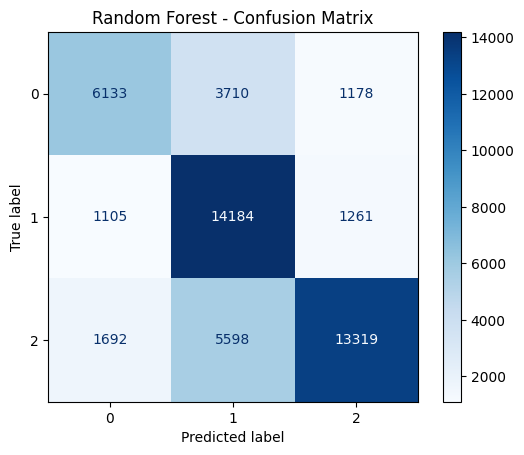

In [43]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest - Confusion Matrix")
plt.show()

##  Deep Learning Models
##### FNN (Feedforward Neural Network)
A fully connected network trained on embeddings of the text.
##### RNN (Recurrent Neural Network)
A sequence model that captures temporal dependencies in text.
##### Stacked RNN
Multiple RNN layers stacked together for learning complex sequence patterns.
##### BiRNN (Bidirectional RNN)
Processes the input sequence in both forward and backward directions to capture context from both sides.